In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

df = pd.read_csv("restaurant_sales_malaysian_data.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194166 entries, 0 to 194165
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     194166 non-null  object 
 1   restaurant_id            194166 non-null  int64  
 2   restaurant_type          194166 non-null  object 
 3   menu_item_name           194166 non-null  object 
 4   meal_type                194166 non-null  object 
 5   key_ingredients_tags     194166 non-null  object 
 6   typical_ingredient_cost  194166 non-null  float64
 7   observed_market_price    194166 non-null  float64
 8   actual_selling_price     194166 non-null  float64
 9   quantity_sold            194166 non-null  float64
 10  has_promotion            194166 non-null  int64  
 11  special_event            194166 non-null  int64  
 12  day_of_week              194166 non-null  object 
 13  holiday                  194166 non-null  int64  
 14  is_w

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,day_of_week,holiday,is_weekend,category,cuisine_type
0,1/1/2024,1,Casual Dining,ABC Special,Lunch,"shaved ice, red beans, corn, ice cream",4.57,12.01,10.2085,10.0,0,0,Monday,0,0,Desserts,Malaysian
1,1/1/2024,2,Fine Dining,ABC Special,Lunch,"shaved ice, red beans, corn, ice cream",4.74,21.12,8.5320,7.0,0,0,Monday,0,0,Desserts,Malaysian
2,1/1/2024,3,Fine Dining,ABC Special,Lunch,"shaved ice, red beans, corn, ice cream",3.46,19.49,6.2280,3.0,0,0,Monday,0,0,Desserts,Malaysian
3,1/1/2024,4,Street Food,ABC Special,Lunch,"shaved ice, red beans, corn, ice cream",4.37,8.24,7.9800,82.0,0,1,Monday,0,0,Desserts,Malaysian
4,1/1/2024,5,Street Food,ABC Special,Lunch,"shaved ice, red beans, corn, ice cream",3.40,5.73,6.3030,55.0,0,0,Monday,0,0,Desserts,Malaysian


In [2]:
# Select target
y = df["actual_selling_price"]

# Select features (drop text-heavy and target columns)
X = df.drop(columns=[
    "actual_selling_price",
    "menu_item_name",
    "key_ingredients_tags",
    "date",
    "restaurant_id"
])


In [3]:
#cell 5

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.shape

(194166, 39)

In [4]:
#cell 7

from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape

((155332, 39), (38834, 39))

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [7]:
#waktunya menjadi pokemon trainer
#RUN ONLY ONCE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
#evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
# Predict on test data
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(3.0618089978271996, np.float64(4.699669718387944), 0.7260705741601557)

In [10]:
# Compare predicted vs actual for 5 examples
comparison = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred[:5]
})

comparison

,Actual Price,Predicted Price
0,5.508,7.473031
1,9.010,12.930830
2,7.344,16.991544
3,6.282,9.220039
4,22.120,21.412229


In [11]:
#--- leaving machine learning area ---
restaurant_avg_price = (
    df.groupby("restaurant_id")["actual_selling_price"]
    .mean()
    .reset_index()
)

restaurant_avg_price.head()


,restaurant_id,actual_selling_price
0,1,12.206751
1,2,12.748670
2,3,11.957973
3,4,12.839875
4,5,12.728670


In [12]:
#We will classify restaurants using percentiles (data-driven).
q25 = restaurant_avg_price["actual_selling_price"].quantile(0.25)
q50 = restaurant_avg_price["actual_selling_price"].quantile(0.50)
q75 = restaurant_avg_price["actual_selling_price"].quantile(0.75)

q25, q50, q75


(np.float64(15.226294675070747),
 np.float64(17.162878606965172),
 np.float64(17.58476573834197))

In [13]:
#Assign price level
def price_level(avg_price):
    if avg_price <= q25:
        return "Cheap"
    elif avg_price <= q50:
        return "Mid-range"
    elif avg_price <= q75:
        return "Expensive"
    else:
        return "Sultan lo bang?"

restaurant_avg_price["price_level"] = restaurant_avg_price["actual_selling_price"].apply(price_level)

restaurant_avg_price.head()


,restaurant_id,actual_selling_price,price_level
0,1,12.206751,Cheap
1,2,12.748670,Cheap
2,3,11.957973,Cheap
3,4,12.839875,Cheap
4,5,12.728670,Cheap


In [14]:
#cek berapa restoran masuk kategori apa
restaurant_avg_price["price_level"].value_counts()

price_level
Cheap              25
Expensive          25
Mid-range          25
Sultan lo bang?    25
Name: count, dtype: int64

In [15]:
# --- NOW ENTERING PROFIT ESTIMATION AREA ---
df["estimated_cost"] = df["typical_ingredient_cost"]
df["estimated_profit"] = df["actual_selling_price"] - df["estimated_cost"]
df["profit_margin"] = df["estimated_profit"] / df["actual_selling_price"]

In [16]:
df[[
    "restaurant_id",
    "menu_item_name",
    "actual_selling_price",
    "estimated_cost",
    "estimated_profit",
    "profit_margin"
]].head()

,restaurant_id,menu_item_name,actual_selling_price,estimated_cost,estimated_profit,profit_margin
0,1,ABC Special,10.2085,4.57,5.6385,0.552334
1,2,ABC Special,8.5320,4.74,3.7920,0.444444
2,3,ABC Special,6.2280,3.46,2.7680,0.444444
3,4,ABC Special,7.9800,4.37,3.6100,0.452381
4,5,ABC Special,6.3030,3.40,2.9030,0.460574


In [17]:
restaurant_profit = (
    df.groupby("restaurant_id")[["estimated_profit", "profit_margin"]]
    .mean()
    .reset_index()
)

restaurant_profit.head()


,restaurant_id,estimated_profit,profit_margin
0,1,7.114766,0.515983
1,2,7.702382,0.532947
2,3,6.922844,0.511960
3,4,7.719125,0.529586
4,5,7.702523,0.532215


In [18]:
#--- EXPORT THE MODEL AREA ---
import pickle

# Save trained model
with open("price_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save column order (VERY IMPORTANT)
with open("model_columns.pkl", "wb") as f:
    pickle.dump(X_encoded.columns.tolist(), f)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
print(len(y_test), len(y_pred))


38834 38834


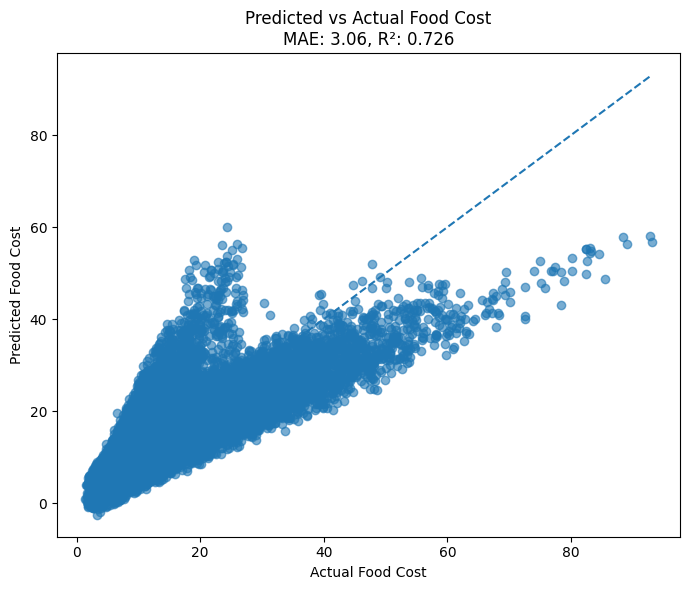

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Food Cost")
plt.ylabel("Predicted Food Cost")
plt.title(f"Predicted vs Actual Food Cost\nMAE: {mae:.2f}, R²: {r2:.3f}")

plt.tight_layout()
plt.show()
